# Plant Efficiency Summary & Energy Waste Quantification

**Abriliam Consulting** — Industrial Energy Management

This final notebook brings together the findings from the diagnostic series to quantify the total energy waste attributable to the identified operational faults. We classify inefficient hours by their dominant cause — chiller performance, pumping excess, or tower fan issues — and estimate the energy (MWh) tied to each fault category.

This is the "so what?" notebook — translating diagnostic findings into actionable business metrics.


In [ ]:
import matplotlib
matplotlib.use('Agg')
# Load the dataset generated in Notebook 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('chiller_plant_data.csv', index_col=0, parse_dates=True)
print(f'Loaded {len(df)} rows, columns: {list(df.columns)}')


In [ ]:
# Compute derived columns needed for this notebook
df['chiller_kw_per_ton'] = df['chiller_kw'] / df['tons']

In [ ]:
# Compute derived columns needed for this notebook
df['chiller_kw_per_ton'] = df['chiller_kw'] / df['tons']

In [70]:
df.columns

Index(['oat_C', 'wb_C', 'occ', 'tons', 'chw_sup_C', 'chw_ret_C', 'chw_dT_C',
       'chw_flow_m3h', 'cw_sup_C', 'cw_ret_C', 'cw_dT_C', 'cw_flow_m3h',
       'approach_C', 'dp_kpa', 'chiller_kw', 'tower_fan_kw', 'chw_pump_kw',
       'cw_pump_kw', 'plant_kw', 'kw_per_ton', 'plant_kw_per_ton',
       'tower_fan_kw_per_ton', 'pumping_kw_per_ton', 'kw_per_ton_15_sma',
       'kw_per_ton_5_sma', 'kw_per_ton_24_sma', 'kw_per_ton_240_sma',
       'chiller_kw_per_ton', 'free_cooling_candidate', 'wb_margin_C',
       'free_cooling', 'freecool_possible_oat', 'freecool_threshold_C',
       'calculated_tons'],
      dtype='object')

=== Energy tied to inefficient operation ===
Timestep assumed: 1.000 h per row
Rows analyzed (after cleaning + load gate): 1,344
Bad rows (plant kW/ton > 4.0): 233 (17.3% of hours)
Energy during bad rows: 99.1 MWh (10.2% of total 971.5 MWh)

=== Subsystem dominance among bad hours ===
 chiller-dominated: 233 hours (100.0%)

Average share of plant kW/ton during bad hours (by component):
      chiller_kw_per_ton: 88.0%
      pumping_kw_per_ton: 6.1%
    tower_fan_kw_per_ton: 5.9%


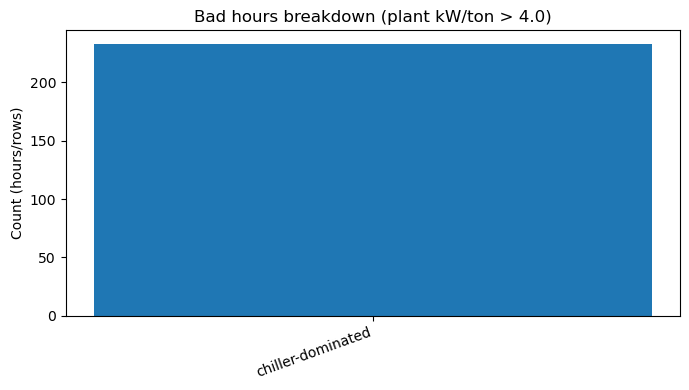

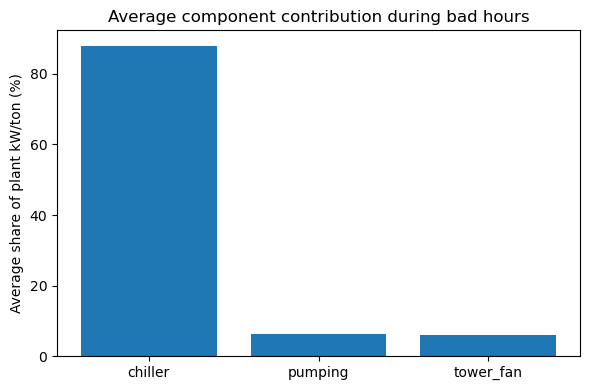

In [71]:
import matplotlib
matplotlib.use('Agg')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG (tune as needed)
# =========================
KW_PER_TON_BAD = 4.0        # threshold for "bad" plant efficiency
MIN_TONS = 20               # ignore tiny loads (set to 0 to disable)
DOMINANCE_FRAC = 0.50       # "dominated by subsystem" if >= this share of plant kW/ton

# =========================
# Helper: estimate timestep hours
# =========================
def infer_timestep_hours(df: pd.DataFrame) -> float:
    # If the index is datetime-like and monotonic, infer typical timestep
    idx = df.index
    if isinstance(idx, pd.DatetimeIndex) and len(idx) >= 3:
        diffs = idx.to_series().diff().dropna().dt.total_seconds() / 3600.0
        if len(diffs) > 0:
            dt = float(diffs.median())
            # guard against weirdness
            if np.isfinite(dt) and dt > 0 and dt < 24*7:
                return dt
    # Otherwise assume 1 row = 1 hour
    return 1.0

dt_hr = infer_timestep_hours(df)

# =========================
# Clean + select columns
# =========================
need_cols = [
    "plant_kw_per_ton", "plant_kw", "tons",
    "pumping_kw_per_ton", "chiller_kw_per_ton"
]
# tower fan per ton is optional
if "tower_fan_kw_per_ton" in df.columns:
    need_cols.append("tower_fan_kw_per_ton")

work = df[need_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

# Optional load gate
if MIN_TONS > 0:
    work = work[work["tons"] >= MIN_TONS].copy()

# =========================
# 1) Energy savings quantification
# =========================
bad = work["plant_kw_per_ton"] > KW_PER_TON_BAD
n_total = len(work)
n_bad = int(bad.sum())

# MWh for "bad hours"
# If each row is dt_hr hours: MWh = sum(kW * hours) / 1000
bad_mwh = float((work.loc[bad, "plant_kw"] * dt_hr).sum() / 1000.0)
total_mwh = float((work["plant_kw"] * dt_hr).sum() / 1000.0)
pct_energy_bad = 100.0 * (bad_mwh / total_mwh) if total_mwh > 0 else np.nan
pct_hours_bad = 100.0 * (n_bad / n_total) if n_total > 0 else np.nan

print("=== Energy tied to inefficient operation ===")
print(f"Timestep assumed: {dt_hr:.3f} h per row")
print(f"Rows analyzed (after cleaning + load gate): {n_total:,}")
print(f"Bad rows (plant kW/ton > {KW_PER_TON_BAD}): {n_bad:,} ({pct_hours_bad:.1f}% of hours)")
print(f"Energy during bad rows: {bad_mwh:,.1f} MWh ({pct_energy_bad:.1f}% of total {total_mwh:,.1f} MWh)")

# =========================
# 2) Subsystem blame assignment (within bad hours)
# =========================
bad_df = work.loc[bad].copy()

# Build per-ton components
comp_cols = ["chiller_kw_per_ton", "pumping_kw_per_ton"]
if "tower_fan_kw_per_ton" in bad_df.columns:
    comp_cols.append("tower_fan_kw_per_ton")

# If plant_kw_per_ton exists, use it; otherwise sum components
plant_kpt = bad_df["plant_kw_per_ton"].copy()

# Avoid divide-by-zero / negative artifacts
plant_kpt = plant_kpt.where(plant_kpt > 0, np.nan)
bad_df = bad_df.loc[plant_kpt.dropna().index].copy()
plant_kpt = plant_kpt.dropna()

# Fractions of plant kW/ton
frac = pd.DataFrame(index=bad_df.index)
for c in comp_cols:
    frac[c] = bad_df[c] / plant_kpt

# Dominance classification
labels = pd.Series("mixed/other", index=bad_df.index)

p_dom = frac["pumping_kw_per_ton"] >= DOMINANCE_FRAC
c_dom = frac["chiller_kw_per_ton"] >= DOMINANCE_FRAC
t_dom = frac["tower_fan_kw_per_ton"] >= DOMINANCE_FRAC if "tower_fan_kw_per_ton" in frac.columns else pd.Series(False, index=bad_df.index)

# Priority logic: if one dominates, tag it; if multiple dominate (rare), tag as mixed/other
labels[p_dom & ~c_dom & ~t_dom] = "pumping-dominated"
labels[c_dom & ~p_dom & ~t_dom] = "chiller-dominated"
if "tower_fan_kw_per_ton" in frac.columns:
    labels[t_dom & ~p_dom & ~c_dom] = "tower-fan-dominated"

share = labels.value_counts(normalize=True).sort_values(ascending=False) * 100
counts = labels.value_counts().sort_values(ascending=False)

print("\n=== Subsystem dominance among bad hours ===")
for k in counts.index:
    print(f"{k:>18}: {counts[k]:,} hours ({share[k]:.1f}%)")

# Also compute average component shares during bad hours (useful even when not "dominated")
avg_frac = frac.clip(lower=-10, upper=10).mean() * 100
print("\nAverage share of plant kW/ton during bad hours (by component):")
for c in avg_frac.index:
    print(f"  {c:>22}: {avg_frac[c]:.1f}%")

# =========================
# Simple visuals (optional)
# =========================
plt.figure(figsize=(7,4))
plt.bar(counts.index, counts.values)
plt.ylabel("Count (hours/rows)")
plt.title(f"Bad hours breakdown (plant kW/ton > {KW_PER_TON_BAD})")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.close("all")

plt.figure(figsize=(6,4))
plt.bar([c.replace("_kw_per_ton","") for c in avg_frac.index], avg_frac.values)
plt.ylabel("Average share of plant kW/ton (%)")
plt.title("Average component contribution during bad hours")
plt.tight_layout()
plt.close("all")


### Energy Waste Quantification

Flagging all hours where plant kW/ton exceeds 4.0 and summing their energy consumption provides a conservative estimate of the energy tied to inefficient operation. The subsystem "blame assignment" uses dominance analysis — if a single subsystem (chiller, pumping, or tower fans) accounts for more than 50% of the plant's kW/ton during a bad hour, that hour is attributed to that subsystem.

The bar charts show:
- **Hours breakdown**: Which subsystem is most often responsible for inefficiency
- **Average component share**: How the plant's per-ton energy consumption splits across subsystems during inefficient periods

This analysis directly informs the priority of corrective actions — addressing the dominant source of waste first yields the largest savings.


Bad hours plotted: 233


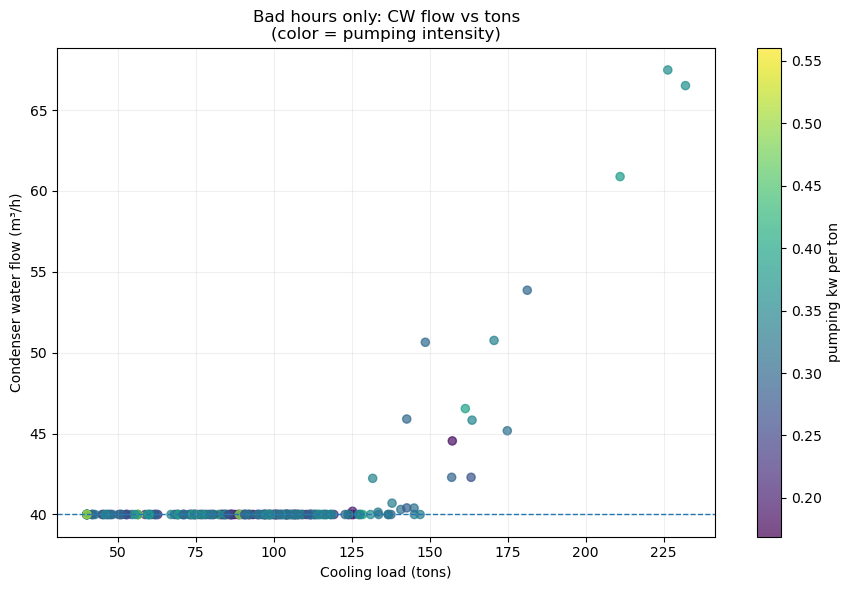

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# CONFIG
# -------------------------------
KWTON_BAD = 4.0
MIN_TONS = 20
FLOW_FLOOR = 40.0        # suspected CW flow floor (m3/h)
COLOR_BY = "pumping_kw_per_ton"  # or "cw_pump_kw"

# -------------------------------
# Prepare bad-hours subset
# -------------------------------
cols = [
    "tons", "cw_flow_m3h", "plant_kw_per_ton",
    "pumping_kw_per_ton", "cw_pump_kw"
]
cols = [c for c in cols if c in df.columns]

d = (
    df[cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["tons", "cw_flow_m3h", "plant_kw_per_ton"])
)

d = d[(d["plant_kw_per_ton"] > KWTON_BAD) & (d["tons"] >= MIN_TONS)]

print(f"Bad hours plotted: {len(d)}")

# -------------------------------
# Scatter plot
# -------------------------------
plt.figure(figsize=(9,6))
sc = plt.scatter(
    d["tons"],
    d["cw_flow_m3h"],
    c=d[COLOR_BY],
    s=35,
    alpha=0.7
)

plt.axhline(FLOW_FLOOR, linestyle="--", linewidth=1)
plt.colorbar(sc, label=COLOR_BY.replace("_", " "))

plt.xlabel("Cooling load (tons)")
plt.ylabel("Condenser water flow (m³/h)")
plt.title("Bad hours only: CW flow vs tons\n(color = pumping intensity)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.close("all")


### CW Flow During Inefficient Hours

Examining condenser water flow during inefficient hours reveals a potential minimum flow constraint. The horizontal dashed line at 40 m³/h suggests a CW pump minimum — even at very low loads, the condenser water flow doesn't drop below this floor. This fixed flow at low loads contributes to the pumping-dominated inefficiency seen in the classification above.

---

## Summary of Findings

Across this seven-notebook diagnostic series, we identified three distinct operational faults in the chiller plant:

1. **Low delta-T syndrome** — CHW temperature differential collapsed from ~6°C to ~4.2°C around early July, forcing higher pump flows and degrading chiller evaporator performance
2. **Cooling tower degradation** — Approach temperature drifted upward by approximately 1.5°C over the 8-week period, increasing condenser pressure and chiller power consumption
3. **Night-time fan control bias** — Tower fans operate at elevated power during overnight hours despite minimal cooling loads

### Recommended Actions

| Priority | Action | Expected Impact |
|----------|--------|----------------|
| 1 | Investigate and correct the cause of low CHW delta-T (likely a control valve or bypass issue) | Reduce pump energy by 20-30%, improve chiller efficiency |
| 2 | Inspect and clean cooling tower fill; check fan belt tension and blade pitch | Recover 1-1.5°C of approach, reducing chiller power |
| 3 | Implement load-based fan speed control with overnight setback | Eliminate unnecessary fan energy during low-load hours |
| 4 | Review CW pump minimum flow setpoint | Right-size the flow floor to actual minimum condenser requirements |
